# Notebook 01 — Why Linear Algebra for Biology

**Module:** 04 — Linear Algebra  
**Notebook:** 01 of 10  
**Prerequisites:** Module 01 (NumPy), Module 03 NB02 (expression data)  
**Time estimate:** 45 minutes

---
## Step 1 — Motivation

Biology generates matrices. An RNA-seq experiment produces a matrix:
genes × samples, each entry a read count. A single-cell experiment: cells × genes.
A protein interaction network: proteins × proteins (adjacency matrix).
Linear algebra is the language for asking questions about these matrices.

This module is Tier 2 — Working competence. The goal is not to derive theorems
from axioms, but to be able to implement PCA from scratch, interpret what
eigenvectors mean biologically, and formulate regression as a projection.

---
## Step 2 — Intuition

Three killer applications of linear algebra in biology:

1. **PCA on expression data:** 20,000-gene expression profiles are impossible to
   visualize. PCA compresses them into 2–3 dimensions that capture the most
   variation. The math: eigendecomposition of the covariance matrix.

2. **Gene regulatory networks:** If gene A activates gene B, draw a directed edge
   A→B. The adjacency matrix $A_{ij} = 1$ if i→j. Spectral analysis of this
   matrix reveals modules (communities) in the network.

3. **Linear regression / eQTL:** 'Does SNP genotype predict expression?' is the
   question; solving $\mathbf{X}^\top \mathbf{X} \hat{\boldsymbol{\beta}} = \mathbf{X}^\top \mathbf{y}$
   is the answer — pure linear algebra.

---
## Step 3 — Biological Background

**Expression matrix:**
- Rows = genes (features), columns = samples (observations)
- Each entry $x_{gs}$ = expression level of gene $g$ in sample $s$
- Typical dimensions: 20,000 genes × 100 samples for bulk RNA-seq;
  30,000 genes × 10,000 cells for single-cell

**Why high-dimensional data is hard:**
- Distance behaves strangely in high dimensions (curse of dimensionality)
- Visualizing 20,000 axes is impossible
- Statistical tests lose power with many features relative to samples

**Linear algebra's role:**
- **Dimensionality reduction** (PCA, SVD): compress while preserving structure
- **Clustering** (spectral clustering via Laplacian): find groups
- **Regression** (eQTL, DE): model relationships between variables

---
## Step 4 — Mathematical Explanation

**The expression matrix as a linear algebra object:**

$$\mathbf{X} \in \mathbb{R}^{G \times S}$$

where $G$ = number of genes, $S$ = number of samples.

**Three key operations:**

| Operation | Formula | Biological meaning |
|-----------|---------|-------------------|
| Covariance matrix | $\mathbf{C} = \frac{1}{S-1}\mathbf{X}^\top \mathbf{X}$ (centered) | How genes co-vary across samples |
| Gram matrix | $\mathbf{G} = \frac{1}{G-1}\mathbf{X} \mathbf{X}^\top$ | How samples relate to each other |
| Linear system | $\mathbf{X}\boldsymbol{\beta} = \mathbf{y}$ | Regression: predict $y$ from gene expression |

The **rank** of $\mathbf{X}$ is the number of linearly independent rows/columns —
roughly, the number of 'independent signals' in the data. For most expression
matrices, $\text{rank}(\mathbf{X}) = \min(G, S)$, which for bulk RNA-seq is $S$
(far fewer samples than genes).

---
## Step 6 — Python Implementation

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Cell 6.1 — Construct a toy expression matrix and inspect its structure
rng = np.random.default_rng(42)

n_genes, n_samples = 500, 20
# 3 hidden 'cell types' — each sample belongs to one type
cell_type = rng.choice(3, n_samples)       # 0, 1, or 2
# Each cell type has a characteristic expression profile
type_profiles = rng.normal(0, 2, (3, n_genes))   # (cell_types, genes)
# Observed expression = type profile + noise
X = type_profiles[cell_type] + rng.normal(0, 0.5, (n_samples, n_genes))
# Transpose to genes × samples (standard RNA-seq convention)
X = X.T    # shape: (n_genes, n_samples)

print(f"Expression matrix X: {X.shape}  (genes × samples)")
print(f"Matrix rank: {np.linalg.matrix_rank(X)} (should be ≤ min(500, 20) = 20)")
print(f"Frobenius norm ‖X‖_F = {np.linalg.norm(X, 'fro'):.2f}")

Expression matrix X: (500, 20)  (genes × samples)
Matrix rank: 20 (should be ≤ min(500, 20) = 20)
Frobenius norm ‖X‖_F = 207.07


In [3]:
# Cell 6.2 — Three key derived matrices
# Center: subtract the mean expression of each gene across samples
X_centered = X - X.mean(axis=1, keepdims=True)

# 1. Sample covariance matrix: how genes co-vary (S × S)
C_samples = (X_centered.T @ X_centered) / (n_genes - 1)   # (samples, samples)

# 2. Gene covariance matrix: which genes are co-expressed (G × G) — large!
#    We don't compute the full one here, but its eigenstructure is exactly PCA

# 3. Adjacency matrix preview: gene-gene correlation
gene_subset = X_centered[:50]   # first 50 genes for visualisation
norms = np.linalg.norm(gene_subset, axis=1, keepdims=True)
cos_sim = (gene_subset @ gene_subset.T) / (norms @ norms.T + 1e-12)

print(f"Sample covariance matrix: {C_samples.shape}")
print(f"Gene-gene cosine similarity (50×50): {cos_sim.shape}")
print(f"Diagonal of sample covariance (should be per-gene variance): {np.diag(C_samples)[:5].round(3)}")

Sample covariance matrix: (20, 20)
Gene-gene cosine similarity (50×50): (50, 50)
Diagonal of sample covariance (should be per-gene variance): [3.454 2.043 3.448 3.543 3.49 ]


---
## Step 7 — Visualization

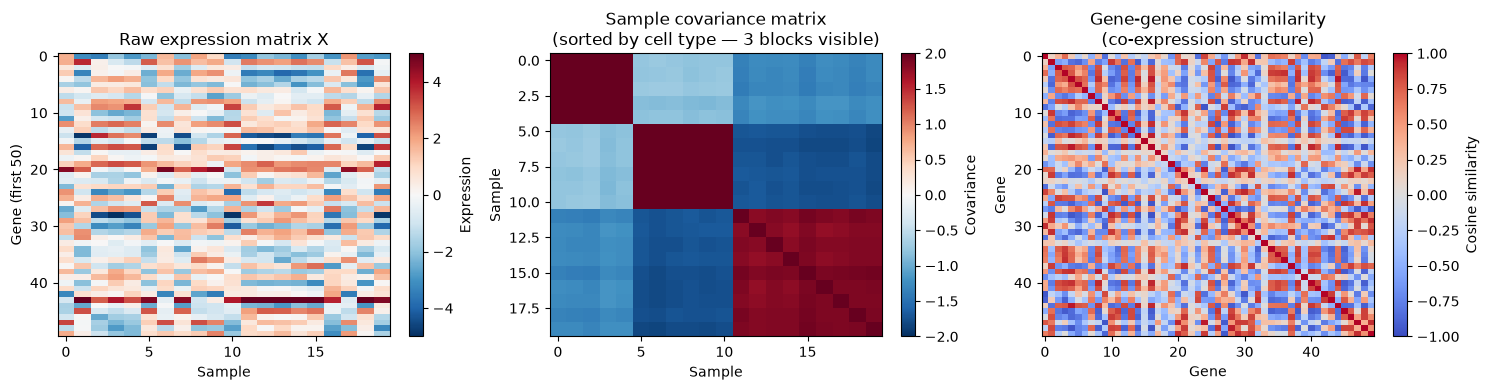

In [4]:
# Cell 7.1 — Three perspectives on the expression matrix
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Panel 1: Raw expression matrix (first 50 genes)
ax = axes[0]
im = ax.imshow(X[:50], aspect='auto', cmap='RdBu_r', vmin=-5, vmax=5, interpolation='none')
plt.colorbar(im, ax=ax, fraction=0.04, label='Expression')
ax.set_xlabel('Sample'); ax.set_ylabel('Gene (first 50)')
ax.set_title('Raw expression matrix X')

# Panel 2: Sample covariance matrix — block structure = 3 cell types
ax = axes[1]
order = np.argsort(cell_type)   # sort samples by cell type to reveal blocks
im2 = ax.imshow(C_samples[np.ix_(order, order)], aspect='auto', cmap='RdBu_r',
                vmin=-2, vmax=2, interpolation='none')
plt.colorbar(im2, ax=ax, fraction=0.04, label='Covariance')
ax.set_xlabel('Sample'); ax.set_ylabel('Sample')
ax.set_title('Sample covariance matrix\n(sorted by cell type — 3 blocks visible)')

# Panel 3: Gene-gene cosine similarity (first 50 genes)
ax = axes[2]
im3 = ax.imshow(cos_sim, aspect='auto', cmap='coolwarm', vmin=-1, vmax=1, interpolation='none')
plt.colorbar(im3, ax=ax, fraction=0.04, label='Cosine similarity')
ax.set_xlabel('Gene'); ax.set_ylabel('Gene')
ax.set_title('Gene-gene cosine similarity\n(co-expression structure)')

plt.tight_layout()
plt.show()

---
## Step 8 — Exercises

1. What is the rank of a 500-gene × 20-sample expression matrix? Why can't it exceed
   20? What does this mean geometrically about the data?
2. Compute the Frobenius norm of `X` and `X_centered`. Which is larger? Why?
3. The sample covariance matrix is 20×20 even though there are 500 genes. Write one
   sentence explaining why this is not a contradiction.
4. If two genes have cosine similarity ≈ 1, what does that mean biologically? If ≈ −1?

---
## Quiz — Active Recall

1. Name three biological problems where the data is naturally a matrix.
2. What is the rank of a matrix? What limits the rank of a typical RNA-seq matrix?
3. What is the Frobenius norm? Write the formula.
4. What does centering a matrix do, and why is it required before PCA?
5. What is the difference between the sample covariance matrix (S×S) and the
   gene covariance matrix (G×G)? Which is more computationally tractable?

---
## Reflection

**Date completed:** ____________________

> *[Can you name three biological questions that linear algebra can answer that scalar arithmetic cannot?]*

---
*Next: `02_vectors_dot_products_norms.ipynb`*